<a href="https://colab.research.google.com/github/vivek1905/Vivek_Foundations-of-AI-code-for-the-Final-Report/blob/main/Vivek_FAI_Code_for_Capstone_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
# Import Libraries
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt
import random

In [37]:
# Set random seed for reproducibility
np.random.seed(42)
random.seed(42)

In [38]:
# Environment Setup
env = gym.make("FrozenLake-v1", is_slippery=True)

state_size = env.observation_space.n
action_size = env.action_space.n

print("State size:", state_size)
print("Action size:", action_size)

State size: 16
Action size: 4


In [39]:
# Initialize Q-table
q_table = np.zeros((state_size, action_size))

print(q_table)

[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


In [40]:
# Hyperparameters

learning_rate = 0.1
discount_factor = 0.99

epsilon = 1.0
epsilon_decay = 0.995
min_epsilon = 0.01

episodes = 5000
max_steps = 100

In [41]:
# Tracking Metrics
rewards = []
success_rate = []

# Training Loop
for episode in range(episodes):

    state, _ = env.reset()
    total_reward = 0

    for step in range(max_steps):

        # Exploration vs Exploitation
        if np.random.uniform(0,1) < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(q_table[state])
        next_state, reward, terminated, truncated, _ = env.step(action)

        # Q-Learning Update
        q_table[state, action] = q_table[state, action] + learning_rate * (
            reward + discount_factor * np.max(q_table[next_state]) - q_table[state, action]
        )

        state = next_state
        total_reward += reward

        if terminated or truncated:
            break

    # Update Exploration Rate
    epsilon = max(min_epsilon, epsilon * epsilon_decay)

    rewards.append(total_reward)
    success = 1 if total_reward > 0 else 0
    success_rate.append(success)

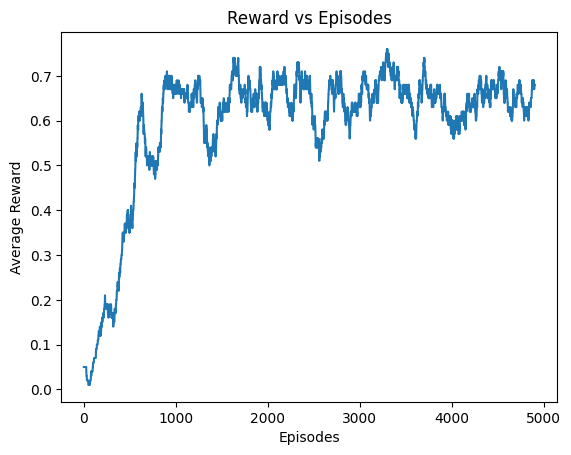

In [42]:
# Plot results for reward curve
plt.figure()
plt.plot(np.convolve(rewards, np.ones(100)/100, mode='valid'))
plt.title("Reward vs Episodes")
plt.xlabel("Episodes")
plt.ylabel("Average Reward")
plt.savefig("reward_plot.png")
plt.show()

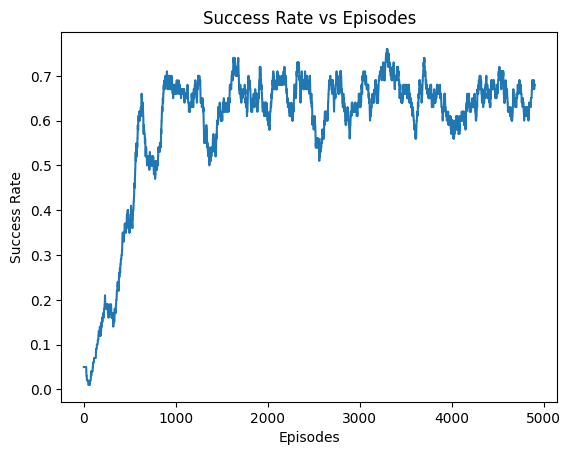

In [43]:
# Plot results for success rate curve
plt.figure()
plt.plot(np.convolve(success_rate, np.ones(100)/100, mode='valid'))
plt.title("Success Rate vs Episodes")
plt.xlabel("Episodes")
plt.ylabel("Success Rate")
plt.savefig("success_plot.png")
plt.show()

In [44]:
# Test Trained Agent
test_episodes = 100
success = 0

for episode in range(test_episodes):

    state, _ = env.reset()

    for step in range(max_steps):

        action = np.argmax(q_table[state])
        next_state, reward, terminated, truncated, _ = env.step(action)

        state = next_state

        if terminated or truncated:
            success += reward
            break

print("Success Rate:", success / test_episodes)
# Print average reward
print("Average Reward (last 100 episodes):", np.mean(rewards[-100:]))

Success Rate: 0.69
Average Reward (last 100 episodes): 0.68


In [45]:
# Final Outputs
print("Final Q Table:")
print(q_table)

Final Q Table:
[[5.54903969e-01 4.40657599e-01 4.49269006e-01 4.77609510e-01]
 [1.94206511e-01 6.23316735e-02 6.47200910e-02 9.63638355e-02]
 [2.06945549e-02 1.68440768e-01 5.38925896e-02 2.88107937e-02]
 [3.70544632e-04 8.78076092e-02 1.08900951e-08 2.13831069e-02]
 [5.73719920e-01 3.24451900e-01 3.37185468e-01 2.42296712e-01]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [2.69672793e-01 1.02251077e-01 1.83574023e-02 2.00796988e-02]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [3.90365811e-01 3.63427020e-01 4.36265761e-01 6.06597550e-01]
 [4.78708435e-01 6.35105999e-01 4.50025482e-01 5.25284405e-01]
 [5.45891491e-01 3.77676750e-01 3.87274288e-01 3.32594363e-01]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [2.21081154e-01 6.17422907e-01 7.25112385e-01 5.35919460e-01]
 [6.48911392e-01 8.59462500e-01 6.82406447e-01 6.91907096e-01]
 [0.00000000e+00 0.00000000e+00 0.000000

In [46]:
# Learned Policy
actions = ['←','↓','→','↑']
policy = np.argmax(q_table, axis=1)

grid = np.array([actions[a] for a in policy]).reshape(4,4)

print("\nLearned Policy:")
print(grid)


Learned Policy:
[['←' '←' '↓' '↓']
 ['←' '←' '←' '←']
 ['↑' '↓' '←' '←']
 ['←' '→' '↓' '←']]
